# Analisis de resultados heuristicos

Este notebook consume los datos generados por `generador_de_datos.ipynb` y organiza la parte analitica de la entrega.

Objetivos de este notebook:
- calcular medias, desviaciones y mejores/peores casos
- comparar metodos por funcion y dimension
- analizar costo en evaluaciones, no solo valor final
- producir tablas y figuras listas para el reporte


In [74]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "datos"
FIGURES_DIR = DATA_DIR / "figuras"
MANIFEST_PATH = DATA_DIR / "manifest_heuristicos.json"

if not DATA_DIR.exists():
    raise FileNotFoundError("No se encontro la carpeta datos dentro de heuristicos.")

if not MANIFEST_PATH.exists():
    raise FileNotFoundError("No se encontro manifest_heuristicos.json. Ejecuta primero generador_de_datos.ipynb.")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

with MANIFEST_PATH.open("r", encoding="utf-8") as file:
    manifest = json.load(file)

manifest

{'modulo': 'heuristicos',
 'funciones': ['rosenbrock',
  'rastrigin',
  'schwefel',
  'griewank',
  'goldstein_price',
  'six_hump_camel'],
 'metodos': ['ea', 'pso', 'de'],
 'consumer_notebook': 'analisis_resultados.ipynb',
 'descripcion': 'Datos generados sin graficas ni animaciones.',
 'fecha_referencia': '2026-07-24',
 'filtros_ejecucion': {'selected_functions': None,
  'selected_dimensions': None,
  'selected_methods': None,
  'selected_n_corridas': None,
  'skip_existing_files': True},
 'directorios': {'datos_base': 'heuristicos/datos'},
 'organizacion_corridas': 'heuristicos/datos/<funcion>/<archivo>.json|csv',
 'organizacion_resumenes': 'heuristicos/datos/<funcion>/resumen_<funcion>.json|csv',
 'campos_corridas': ['funcion',
  'nombre_funcion',
  'corrida',
  'semilla',
  'metodo',
  'nombre_metodo',
  'dimension',
  'limites',
  'optimo_conocido',
  'mejor_solucion',
  'mejor_valor',
  'distancia_al_optimo',
  'iteraciones',
  'evaluaciones',
  'best_values_history',
  'paramet

## Carga de datos

In [75]:
run_csv_files = sorted(path for path in DATA_DIR.glob("*/*.csv") if not path.name.startswith("resumen_"))
summary_csv_files = sorted(DATA_DIR.glob("*/resumen_*.csv"))
run_json_files = sorted(path for path in DATA_DIR.glob("*/*.json") if not path.name.startswith("resumen_"))

if not run_csv_files:
    raise FileNotFoundError("No se encontraron archivos de corridas dentro de datos/<funcion>/. Ejecuta primero el generador.")

runs_df = pd.concat((pd.read_csv(path) for path in run_csv_files), ignore_index=True)

if summary_csv_files:
    summary_df = pd.concat((pd.read_csv(path) for path in summary_csv_files), ignore_index=True)
else:
    summary_df = pd.DataFrame()

print("Archivos de corridas encontrados:", len(run_csv_files))
print("Archivos de resumen encontrados:", len(summary_csv_files))
runs_df.head()

Archivos de corridas encontrados: 94
Archivos de resumen encontrados: 6


,caso,nombre_metodo,corrida,mejor_valor,distancia_al_optimo,evaluaciones,promedio_valor,promedio_distancia_al_optimo,promedio_evaluaciones,nombre_funcion,...,desviacion_valor,funcion,semilla,metodo,limites,optimo_conocido,mejor_solucion,iteraciones,best_values_history,parametros
0,Six-Hump Camel 2D,Evolucion diferencial,NaN,-1.031628,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Six-Hump Camel 2D,Evolucion diferencial,NaN,-1.031628,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Six-Hump Camel 2D,Evolucion diferencial,NaN,-1.031628,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Six-Hump Camel 2D,Evolucion diferencial,1.0,-1.031628,1.436594,4840.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Six-Hump Camel 2D,Evolucion diferencial,7.0,-1.031628,1.436594,4840.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
numeric_columns = [
    "corrida",
    "semilla",
    "dimension",
    "mejor_valor",
    "distancia_al_optimo",
    "iteraciones",
    "evaluaciones",
]

for column in numeric_columns:
    runs_df[column] = pd.to_numeric(runs_df[column], errors="coerce")

runs_df = runs_df.dropna(subset=["dimension"]).copy()
runs_df["dimension"] = runs_df["dimension"].astype(int)

runs_df["caso"] = runs_df["nombre_funcion"] + " " + runs_df["dimension"].astype(str) + "D"
runs_df["eficiencia_valor_por_eval"] = runs_df["mejor_valor"] / runs_df["evaluaciones"].replace(0, np.nan)

if summary_df.empty:
    summary_df = (
        runs_df.groupby(["funcion", "nombre_funcion", "metodo", "nombre_metodo", "dimension"], dropna=False)
        .agg(
            n_corridas=("corrida", "count"),
            mejor_valor=("mejor_valor", "min"),
            peor_valor=("mejor_valor", "max"),
            promedio_valor=("mejor_valor", "mean"),
            mediana_valor=("mejor_valor", "median"),
            desviacion_valor=("mejor_valor", "std"),
            mejor_distancia_al_optimo=("distancia_al_optimo", "min"),
            promedio_distancia_al_optimo=("distancia_al_optimo", "mean"),
            promedio_evaluaciones=("evaluaciones", "mean"),
            mediana_evaluaciones=("evaluaciones", "median"),
            promedio_iteraciones=("iteraciones", "mean"),
            mediana_iteraciones=("iteraciones", "median"),
        )
        .reset_index()
    )
    summary_df["desviacion_valor"] = summary_df["desviacion_valor"].fillna(0.0)

summary_df["caso"] = summary_df["nombre_funcion"] + " " + summary_df["dimension"].astype(int).astype(str) + "D"
summary_df["caso_n"] = summary_df["caso"] + " | n=" + summary_df["n_corridas"].astype(int).astype(str)
summary_df = summary_df.sort_values(["nombre_funcion", "dimension", "n_corridas", "metodo"]).reset_index(drop=True)
ordered_case_n = summary_df["caso_n"].drop_duplicates().tolist()
summary_df

,funcion,nombre_funcion,metodo,nombre_metodo,dimension,n_corridas,mejor_valor,peor_valor,promedio_valor,mediana_valor,desviacion_valor,mejor_distancia_al_optimo,promedio_distancia_al_optimo,promedio_evaluaciones,mediana_evaluaciones,promedio_iteraciones,mediana_iteraciones,caso,caso_n
0,goldstein_price,Goldstein-Price,de,Evolucion diferencial,2,100,3.000000,3.000000,3.000000,3.000000,9.409453e-15,1.840240e-09,6.059547e-09,4840.0,4840.0,120.0,120.0,Goldstein-Price 2D,Goldstein-Price 2D | n=100
1,goldstein_price,Goldstein-Price,ea,Algoritmo evolutivo,2,100,3.011752,4.336153,3.338019,3.220787,3.697649e-01,6.059783e-03,2.987153e-02,4840.0,4840.0,120.0,120.0,Goldstein-Price 2D,Goldstein-Price 2D | n=100
2,goldstein_price,Goldstein-Price,pso,PSO,2,100,3.000000,3.000000,3.000000,3.000000,1.675337e-12,3.832762e-09,2.783651e-08,4840.0,4840.0,120.0,120.0,Goldstein-Price 2D,Goldstein-Price 2D | n=100
3,goldstein_price,Goldstein-Price,de,Evolucion diferencial,2,500,3.000000,3.000000,3.000000,3.000000,9.812181e-15,1.005919e-09,4.393659e-09,4840.0,4840.0,120.0,120.0,Goldstein-Price 2D,Goldstein-Price 2D | n=500
4,goldstein_price,Goldstein-Price,ea,Algoritmo evolutivo,2,500,3.007420,4.336153,3.208080,3.098265,2.806074e-01,4.104958e-03,2.191061e-02,4840.0,4840.0,120.0,120.0,Goldstein-Price 2D,Goldstein-Price 2D | n=500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,six_hump_camel,Six-Hump Camel,ea,Algoritmo evolutivo,2,500,-1.031556,-1.013471,-1.029222,-1.030392,2.923234e-03,7.269088e-03,1.005735e+00,4840.0,4840.0,120.0,120.0,Six-Hump Camel 2D,Six-Hump Camel 2D | n=500
70,six_hump_camel,Six-Hump Camel,pso,PSO,2,500,-1.031628,-1.031628,-1.031628,-1.031628,6.143328e-14,3.521953e-07,1.065953e+00,4840.0,4840.0,120.0,120.0,Six-Hump Camel 2D,Six-Hump Camel 2D | n=500
71,six_hump_camel,Six-Hump Camel,de,Evolucion diferencial,2,1000,-1.031628,-1.031628,-1.031628,-1.031628,1.634599e-10,1.034882e-07,7.987462e-01,4840.0,4840.0,120.0,120.0,Six-Hump Camel 2D,Six-Hump Camel 2D | n=1000
72,six_hump_camel,Six-Hump Camel,ea,Algoritmo evolutivo,2,1000,-1.031585,-1.013471,-1.029417,-1.030093,2.347016e-03,7.269088e-03,9.606496e-01,4840.0,4840.0,120.0,120.0,Six-Hump Camel 2D,Six-Hump Camel 2D | n=1000


## Tabla base para reporte

In [77]:
tabla_reporte = (
    summary_df[
        [
            "nombre_funcion",
            "dimension",
            "nombre_metodo",
            "n_corridas",
            "mejor_valor",
            "promedio_valor",
            "desviacion_valor",
            "promedio_distancia_al_optimo",
            "promedio_evaluaciones",
        ]
    ]
    .sort_values(["nombre_funcion", "dimension", "nombre_metodo"])
    .reset_index(drop=True)
)

tabla_reporte

,nombre_funcion,dimension,nombre_metodo,n_corridas,mejor_valor,promedio_valor,desviacion_valor,promedio_distancia_al_optimo,promedio_evaluaciones
0,Goldstein-Price,2,Algoritmo evolutivo,100,3.011752,3.338019,3.697649e-01,2.987153e-02,4840.0
1,Goldstein-Price,2,Algoritmo evolutivo,500,3.007420,3.208080,2.806074e-01,2.191061e-02,4840.0
2,Goldstein-Price,2,Algoritmo evolutivo,1000,3.007420,3.199833,2.531059e-01,2.152912e-02,4840.0
3,Goldstein-Price,2,Evolucion diferencial,100,3.000000,3.000000,9.409453e-15,6.059547e-09,4840.0
4,Goldstein-Price,2,Evolucion diferencial,500,3.000000,3.000000,9.812181e-15,4.393659e-09,4840.0
...,...,...,...,...,...,...,...,...,...
69,Six-Hump Camel,2,Evolucion diferencial,500,-1.031628,-1.031628,2.036880e-10,9.395323e-01,4840.0
70,Six-Hump Camel,2,Evolucion diferencial,1000,-1.031628,-1.031628,1.634599e-10,7.987462e-01,4840.0
71,Six-Hump Camel,2,PSO,100,-1.031628,-1.031628,1.343516e-13,6.608334e-01,4840.0
72,Six-Hump Camel,2,PSO,500,-1.031628,-1.031628,6.143328e-14,1.065953e+00,4840.0


## Mejores y peores casos

In [78]:
mejores_casos = runs_df.nsmallest(15, "mejor_valor")[
    ["caso", "nombre_metodo", "corrida", "mejor_valor", "distancia_al_optimo", "evaluaciones"]
]

peores_casos = runs_df.nlargest(15, "mejor_valor")[
    ["caso", "nombre_metodo", "corrida", "mejor_valor", "distancia_al_optimo", "evaluaciones"]
]

print("Mejores casos globales")
display(mejores_casos)
print("Peores casos globales")
display(peores_casos)

Mejores casos globales


,caso,nombre_metodo,corrida,mejor_valor,distancia_al_optimo,evaluaciones
107,Six-Hump Camel 2D,Evolucion diferencial,NaN,-1.031628,NaN,NaN
108,Six-Hump Camel 2D,Evolucion diferencial,NaN,-1.031628,NaN,NaN
109,Six-Hump Camel 2D,Evolucion diferencial,NaN,-1.031628,NaN,NaN
43313,Six-Hump Camel 2D,Evolucion diferencial,1.0,-1.031628,1.436594,4840.0
43319,Six-Hump Camel 2D,Evolucion diferencial,7.0,-1.031628,1.436594,4840.0
43331,Six-Hump Camel 2D,Evolucion diferencial,19.0,-1.031628,1.436594,4840.0
43340,Six-Hump Camel 2D,Evolucion diferencial,28.0,-1.031628,1.436594,4840.0
43341,Six-Hump Camel 2D,Evolucion diferencial,29.0,-1.031628,1.436594,4840.0
43349,Six-Hump Camel 2D,Evolucion diferencial,37.0,-1.031628,1.436594,4840.0
43350,Six-Hump Camel 2D,Evolucion diferencial,38.0,-1.031628,1.436594,4840.0


Peores casos globales


,caso,nombre_metodo,corrida,mejor_valor,distancia_al_optimo,evaluaciones
41791,Schwefel 3D,PSO,79.0,356.832102,1171.164607,7050.0
41800,Schwefel 3D,PSO,88.0,356.832102,1171.164607,7050.0
41809,Schwefel 3D,PSO,97.0,356.832102,1171.164607,7050.0
41891,Schwefel 3D,PSO,79.0,356.832102,1171.164607,7050.0
41900,Schwefel 3D,PSO,88.0,356.832102,1171.164607,7050.0
41909,Schwefel 3D,PSO,97.0,356.832102,1171.164607,7050.0
42891,Schwefel 3D,PSO,79.0,356.832102,1171.164607,7050.0
42900,Schwefel 3D,PSO,88.0,356.832102,1171.164607,7050.0
42909,Schwefel 3D,PSO,97.0,356.832102,1171.164607,7050.0
41781,Schwefel 3D,PSO,69.0,236.876707,1023.174598,7050.0


## Ranking por caso

Se prioriza valor promedio, luego cercania promedio al optimo y luego costo promedio en evaluaciones.

In [79]:
ranking_por_caso = (
    summary_df.sort_values(
        ["caso", "promedio_valor", "promedio_distancia_al_optimo", "promedio_evaluaciones"]
    )
    .groupby("caso", as_index=False)
    .first()[
        [
            "caso",
            "nombre_metodo",
            "promedio_valor",
            "promedio_distancia_al_optimo",
            "promedio_evaluaciones",
        ]
    ]
)

ranking_por_caso

,caso,nombre_metodo,promedio_valor,promedio_distancia_al_optimo,promedio_evaluaciones
0,Goldstein-Price 2D,Evolucion diferencial,3.000000e+00,4.393659e-09,4840.0
1,Griewank 2D,Evolucion diferencial,2.150460e-03,7.927933e-01,7050.0
2,Griewank 3D,PSO,9.002913e-03,4.826982e+00,7050.0
3,Rastrigin 2D,Evolucion diferencial,7.571831e-12,8.089109e-08,4840.0
4,Rastrigin 3D,Evolucion diferencial,1.597214e-02,4.741411e-03,4840.0
5,Rosenbrock 2D,Evolucion diferencial,7.908427e-13,6.003521e-07,4840.0
6,Schwefel 2D,Evolucion diferencial,2.545513e-05,6.148978e-07,7050.0
7,Schwefel 3D,Evolucion diferencial,3.819315e-05,2.265668e-04,7050.0
8,Six-Hump Camel 2D,PSO,-1.031628e+00,1.110487e+00,4840.0


## Figuras para reporte

In [80]:
method_colors = {
    "Algoritmo evolutivo": "#4C78A8",
    "PSO": "#F58518",
    "Evolucion diferencial": "#54A24B",
}

def save_current_figure(filename: str) -> Path:
    path = FIGURES_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    return path


### 3. Distribuciones por metodo

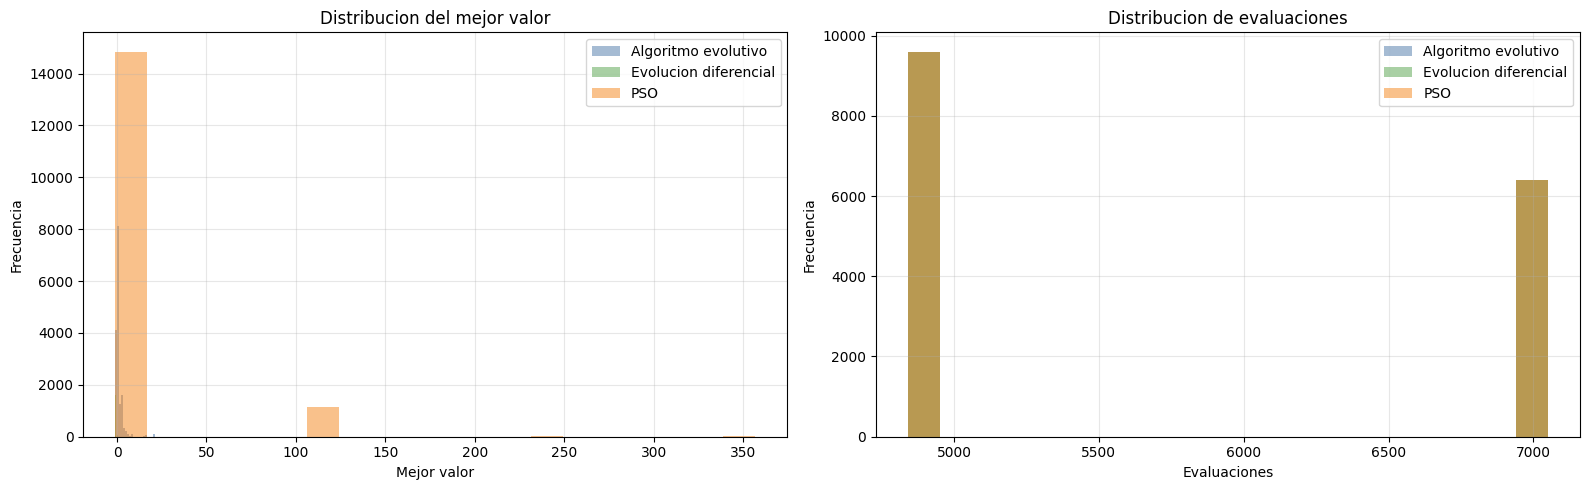

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/heuristicos/datos/figuras/03_histogramas_por_metodo.png')

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
method_names = list(dict.fromkeys(runs_df["nombre_metodo"]))

for method_name in method_names:
    subset = runs_df[runs_df["nombre_metodo"] == method_name]
    color = method_colors.get(method_name, "#777777")
    axes[0].hist(subset["mejor_valor"], bins=20, alpha=0.5, label=method_name, color=color)
    axes[1].hist(subset["evaluaciones"], bins=20, alpha=0.5, label=method_name, color=color)

axes[0].set_title("Distribucion del mejor valor")
axes[0].set_xlabel("Mejor valor")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(alpha=0.3)

axes[1].set_title("Distribucion de evaluaciones")
axes[1].set_xlabel("Evaluaciones")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(alpha=0.3)

axes[0].legend()
axes[1].legend()
plt.tight_layout()
fig_path = save_current_figure("03_histogramas_por_metodo.png")
plt.show()
fig_path

### 4. Comparacion por caso

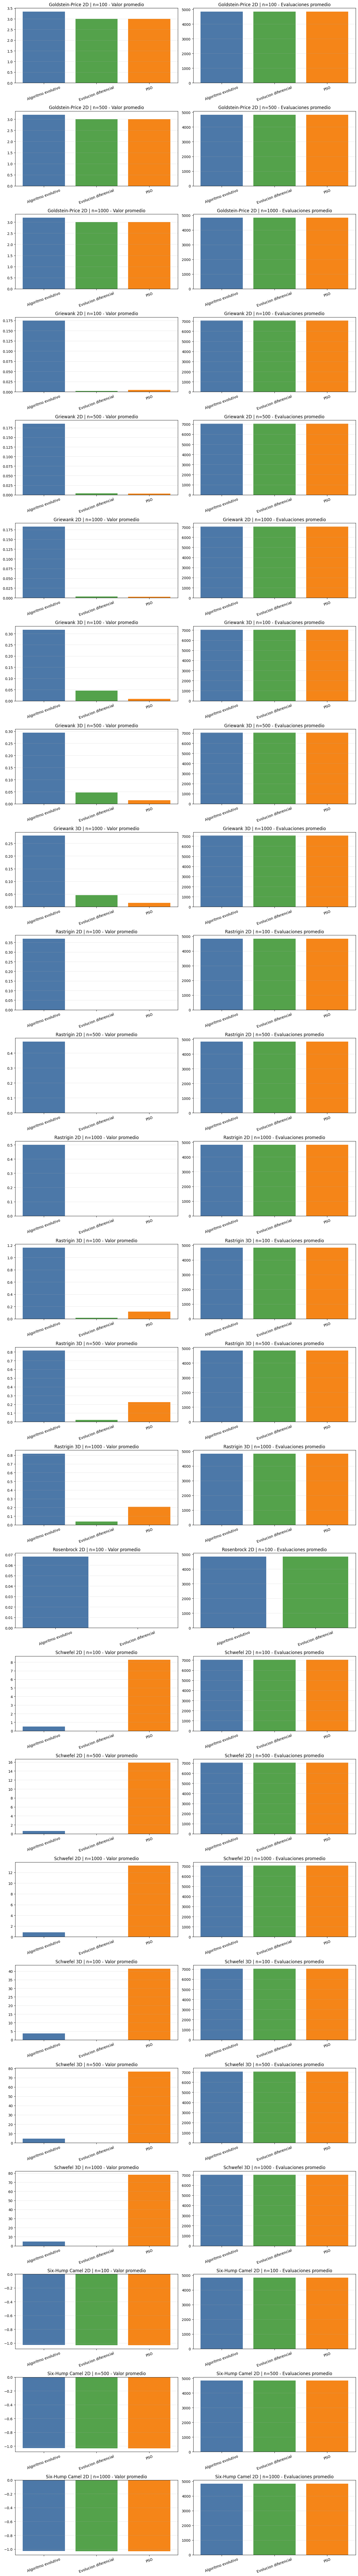

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/heuristicos/datos/figuras/04_comparacion_por_caso.png')

In [84]:
ordered_cases = ordered_case_n
n_cases = len(ordered_cases)
fig, axes = plt.subplots(n_cases, 2, figsize=(14, max(4 * n_cases, 10)))

if n_cases == 1:
    axes = np.array([axes])

for row_index, case_name in enumerate(ordered_cases):
    case_data = summary_df[summary_df["caso_n"] == case_name].sort_values("nombre_metodo")
    colors = [method_colors.get(name, "#777777") for name in case_data["nombre_metodo"]]

    axes[row_index, 0].bar(case_data["nombre_metodo"], case_data["promedio_valor"], color=colors)
    axes[row_index, 0].set_title(f"{case_name} - Valor promedio")
    axes[row_index, 0].tick_params(axis="x", rotation=20)
    axes[row_index, 0].grid(axis="y", alpha=0.3)

    axes[row_index, 1].bar(case_data["nombre_metodo"], case_data["promedio_evaluaciones"], color=colors)
    axes[row_index, 1].set_title(f"{case_name} - Evaluaciones promedio")
    axes[row_index, 1].tick_params(axis="x", rotation=20)
    axes[row_index, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
fig_path = save_current_figure("04_comparacion_por_caso.png")
plt.show()
fig_path

### 5. Graficas de convergencia

Estas curvas requieren que cada archivo JSON de corridas incluya `best_values_history`. Si todavia no aparece ese campo, hay que volver a ejecutar el generador.

In [ ]:
def load_json_runs() -> list[dict]:
    all_rows = []
    for json_path in run_json_files:
        with json_path.open("r", encoding="utf-8") as file:
            rows = json.load(file)
        for row in rows:
            row["source_file"] = json_path.name
            all_rows.append(row)
    return all_rows

json_runs = load_json_runs()
has_histories = any("best_values_history" in row for row in json_runs)
print("Hay historiales de convergencia disponibles:", has_histories)

Hay historiales de convergencia disponibles: True


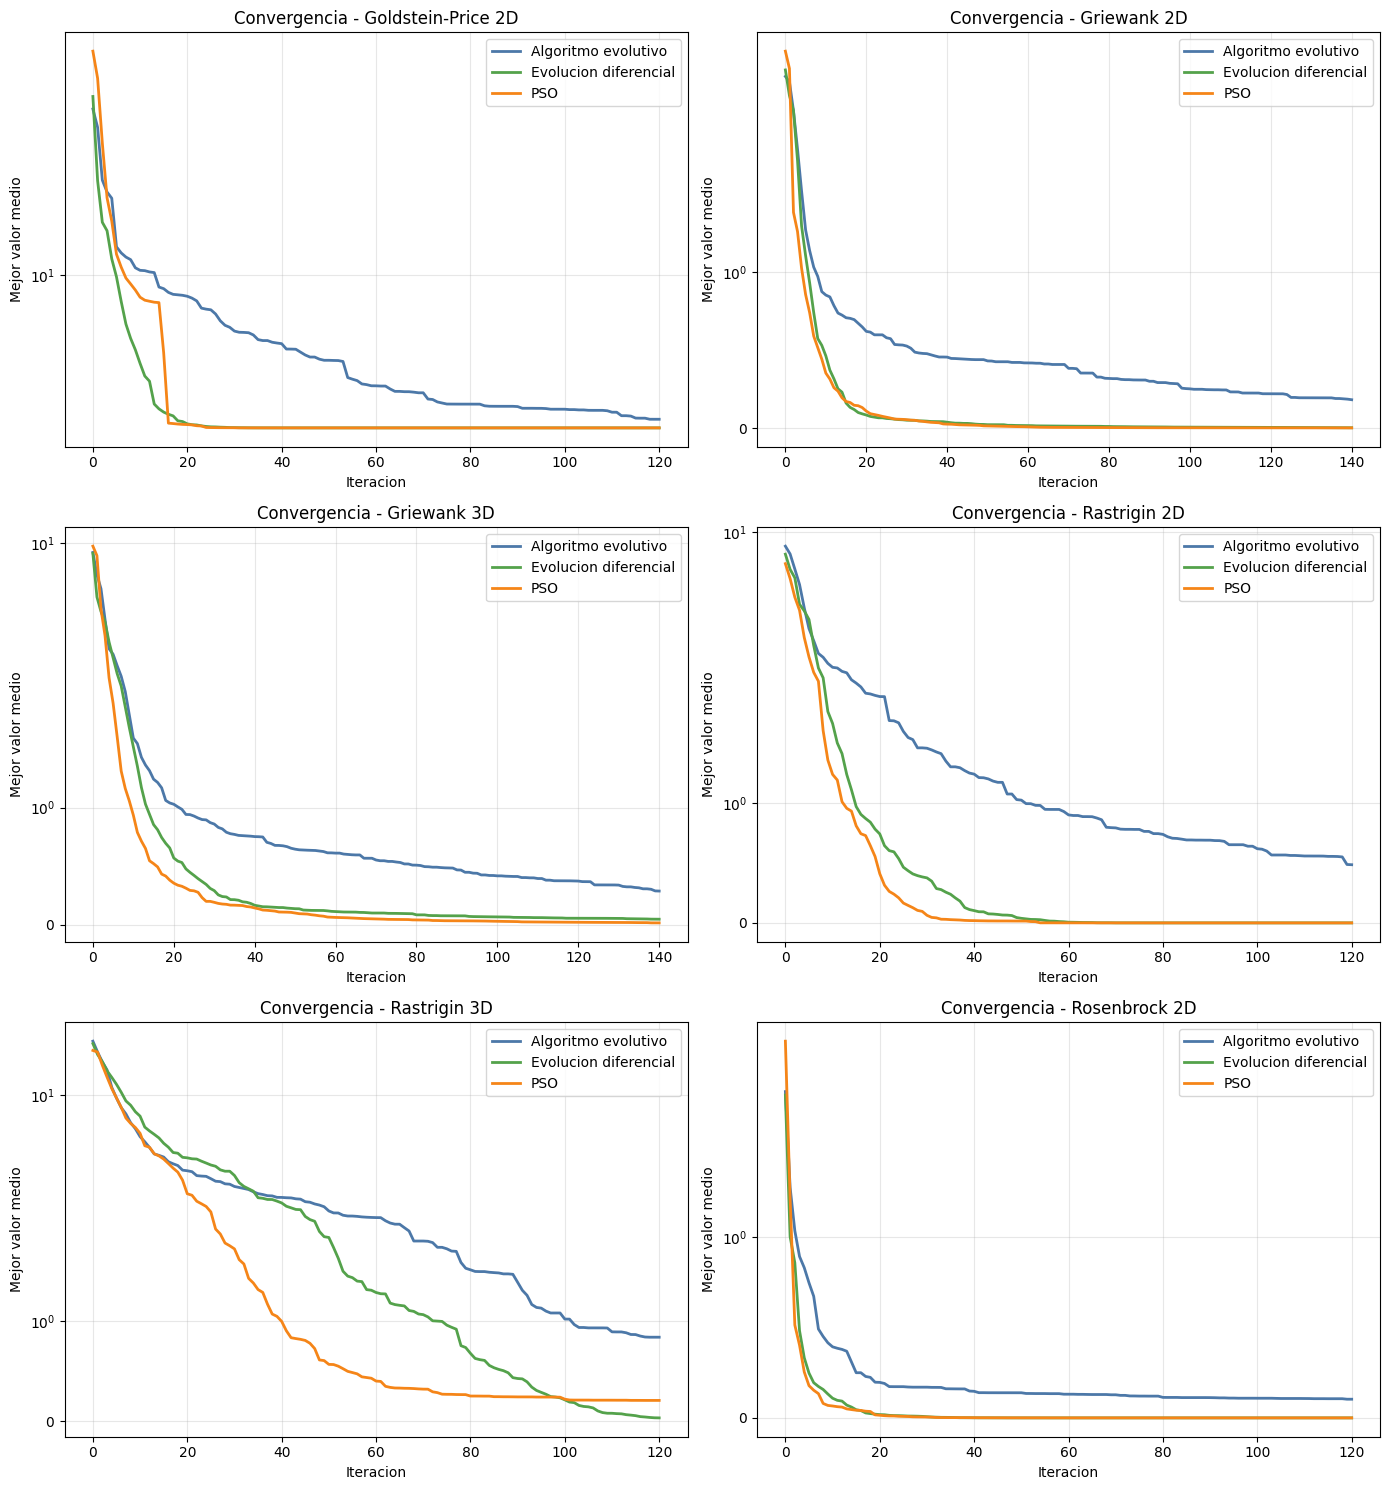

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/heuristicos/datos/figuras/05_convergencia_por_caso.png')

In [ ]:
if has_histories:
    convergence_rows = [row for row in json_runs if "best_values_history" in row and row["best_values_history"]]
    convergence_cases = sorted({f"{row['nombre_funcion']} {row['dimension']}D" for row in convergence_rows})

    if convergence_cases:
        selected_cases = convergence_cases[: min(6, len(convergence_cases))]
        n_cols = 2
        n_rows = int(np.ceil(len(selected_cases) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
        axes = np.array(axes).reshape(-1)

        for ax, case_name in zip(axes, selected_cases):
            case_rows = [
                row for row in convergence_rows
                if f"{row['nombre_funcion']} {row['dimension']}D" == case_name
            ]

            for method_name in sorted({row['nombre_metodo'] for row in case_rows}):
                method_histories = [
                    np.asarray(row["best_values_history"], dtype=float)
                    for row in case_rows
                    if row["nombre_metodo"] == method_name
                ]

                min_length = min(len(history) for history in method_histories)
                aligned = np.vstack([history[:min_length] for history in method_histories])
                mean_history = aligned.mean(axis=0)
                color = method_colors.get(method_name, "#777777")
                ax.plot(mean_history, label=method_name, linewidth=2, color=color)

            ax.set_title(f"Convergencia - {case_name}")
            ax.set_xlabel("Iteracion")
            ax.set_ylabel("Mejor valor medio")
            ax.set_yscale("symlog")
            ax.grid(alpha=0.3)
            ax.legend()

        for ax in axes[len(selected_cases):]:
            ax.axis("off")

        plt.tight_layout()
        fig_path = save_current_figure("05_convergencia_por_caso.png")
        plt.show()
        display(fig_path)
    else:
        print("No hay casos con historiales de convergencia para graficar.")
else:
    print("No se encontraron historiales. Vuelve a ejecutar generador_de_datos.ipynb despues de guardar best_values_history.")

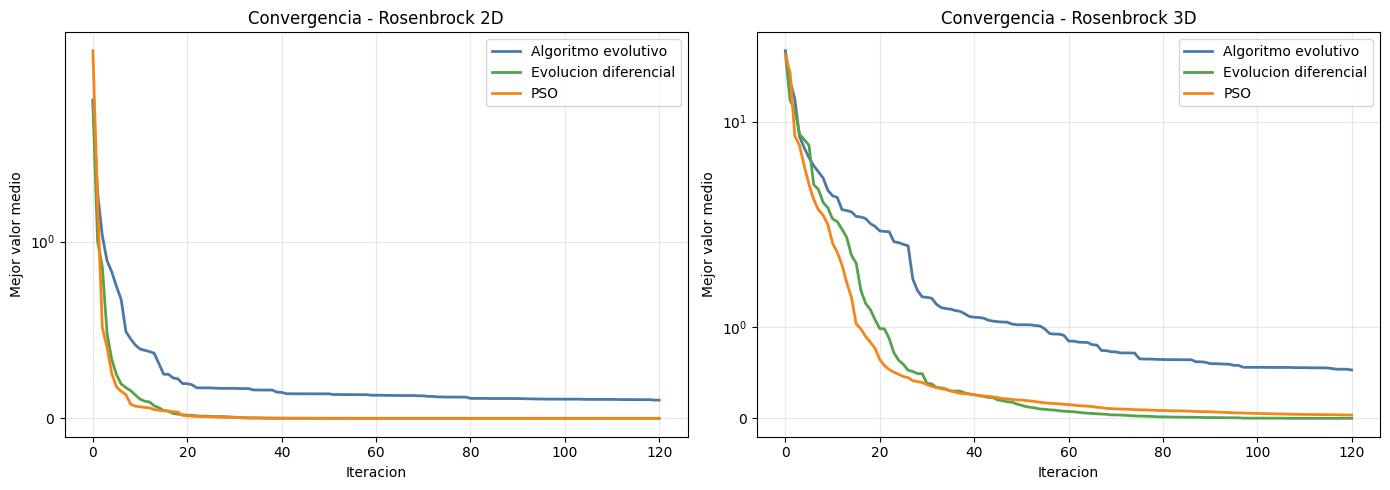

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/heuristicos/datos/figuras/convergencia_rosenbrock_2d_3d.png')

In [ ]:
if has_histories:
    convergence_rows = [
        row for row in json_runs
        if "best_values_history" in row and row["best_values_history"]
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    dimensiones = [2, 3]

    for ax, dim in zip(axes, dimensiones):
        case_rows = [
            row for row in convergence_rows
            if str(row["nombre_funcion"]).lower() == "rosenbrock"
            and int(row["dimension"]) == dim
        ]

        if not case_rows:
            ax.set_title(f"Rosenbrock {dim}D - sin datos")
            ax.axis("off")
            continue

        for method_name in sorted({row["nombre_metodo"] for row in case_rows}):
            method_histories = [
                np.asarray(row["best_values_history"], dtype=float)
                for row in case_rows
                if row["nombre_metodo"] == method_name
            ]

            min_length = min(len(history) for history in method_histories)
            aligned = np.vstack([history[:min_length] for history in method_histories])
            mean_history = aligned.mean(axis=0)

            color = method_colors.get(method_name, "#777777")
            ax.plot(mean_history, label=method_name, linewidth=2, color=color)

        ax.set_title(f"Convergencia - Rosenbrock {dim}D")
        ax.set_xlabel("Iteracion")
        ax.set_ylabel("Mejor valor medio")
        ax.set_yscale("symlog")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    fig_path = save_current_figure("convergencia_rosenbrock_2d_3d.png")
    plt.show()
    display(fig_path)
else:
    print("No se encontraron historiales.")

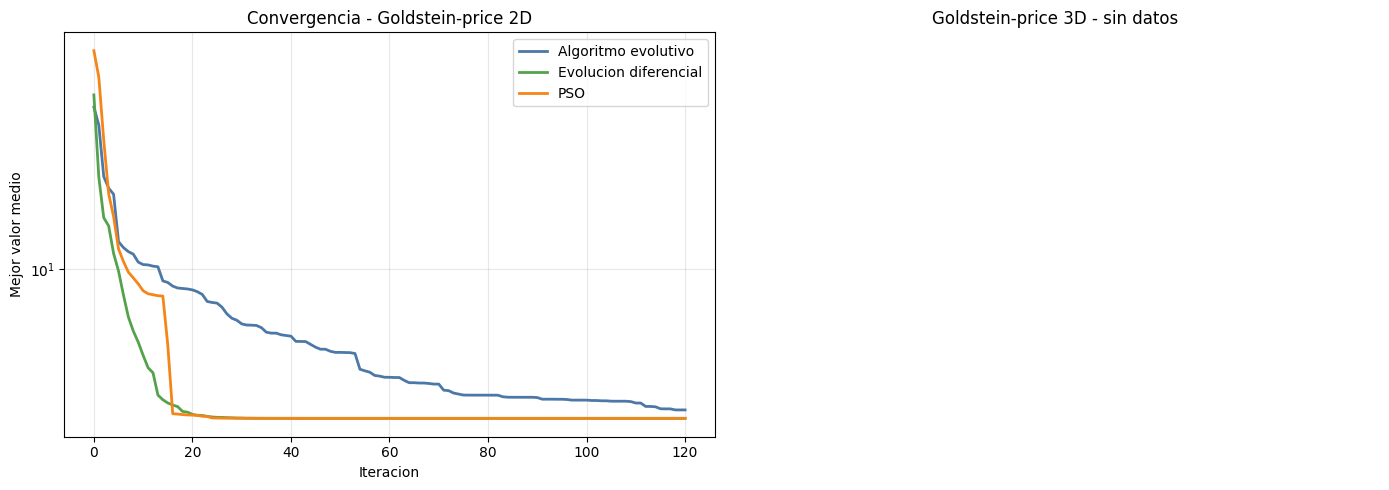

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/heuristicos/datos/figuras/convergencia_goldstein-price_2d_3d.png')

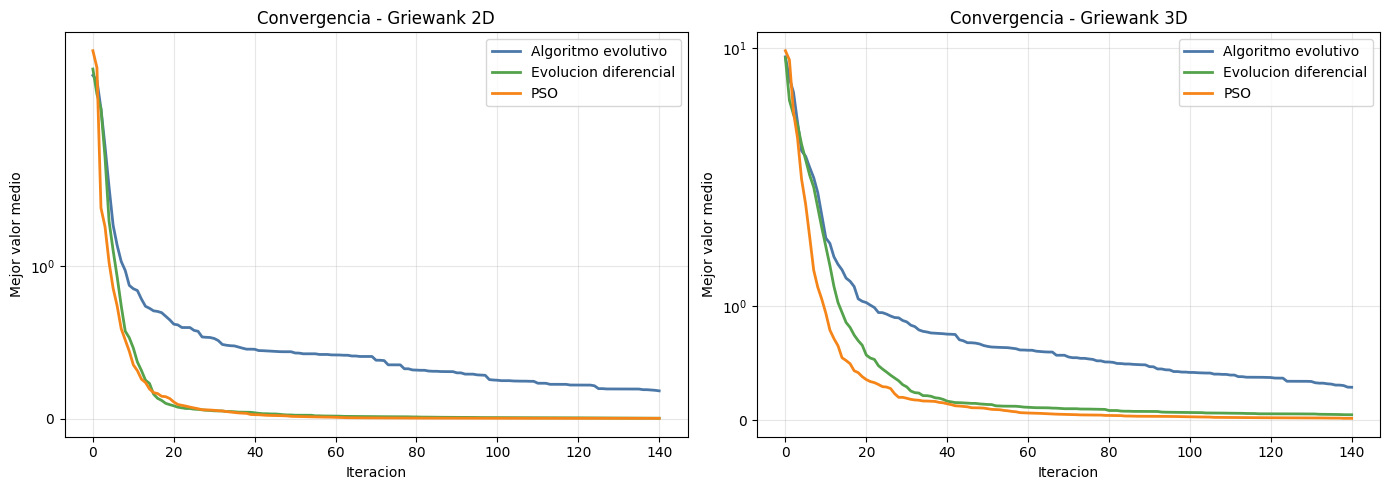

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/heuristicos/datos/figuras/convergencia_griewank_2d_3d.png')

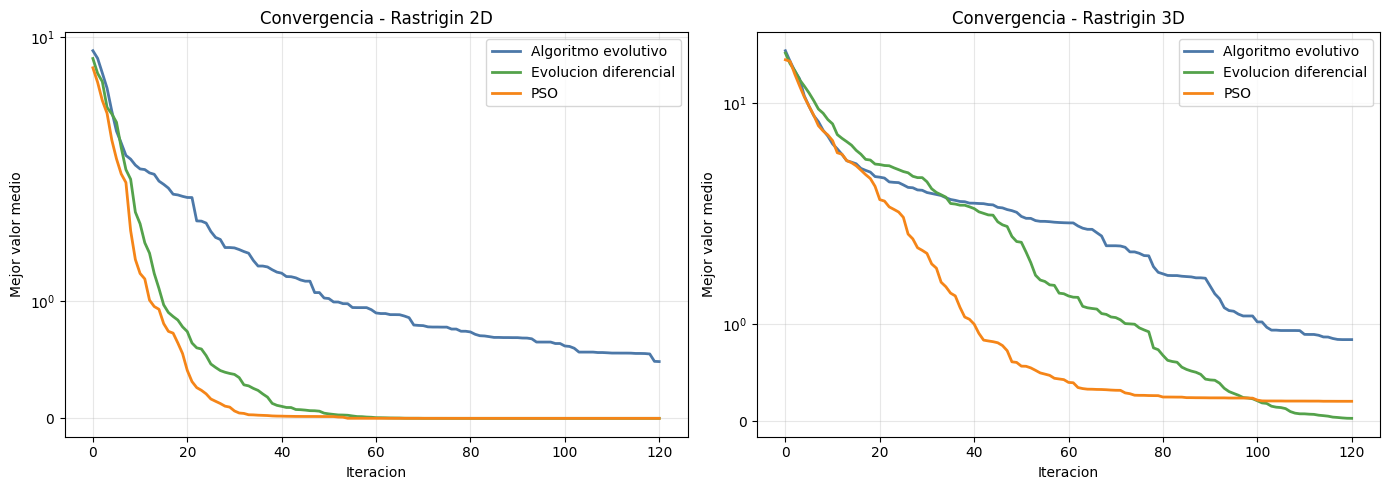

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/heuristicos/datos/figuras/convergencia_rastrigin_2d_3d.png')

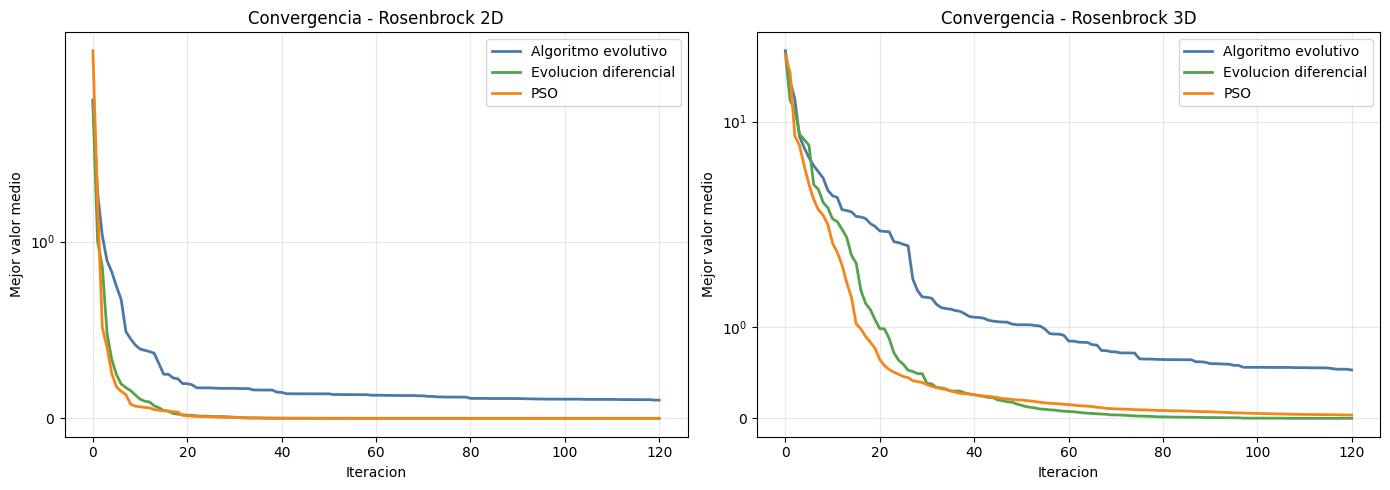

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/heuristicos/datos/figuras/convergencia_rosenbrock_2d_3d.png')

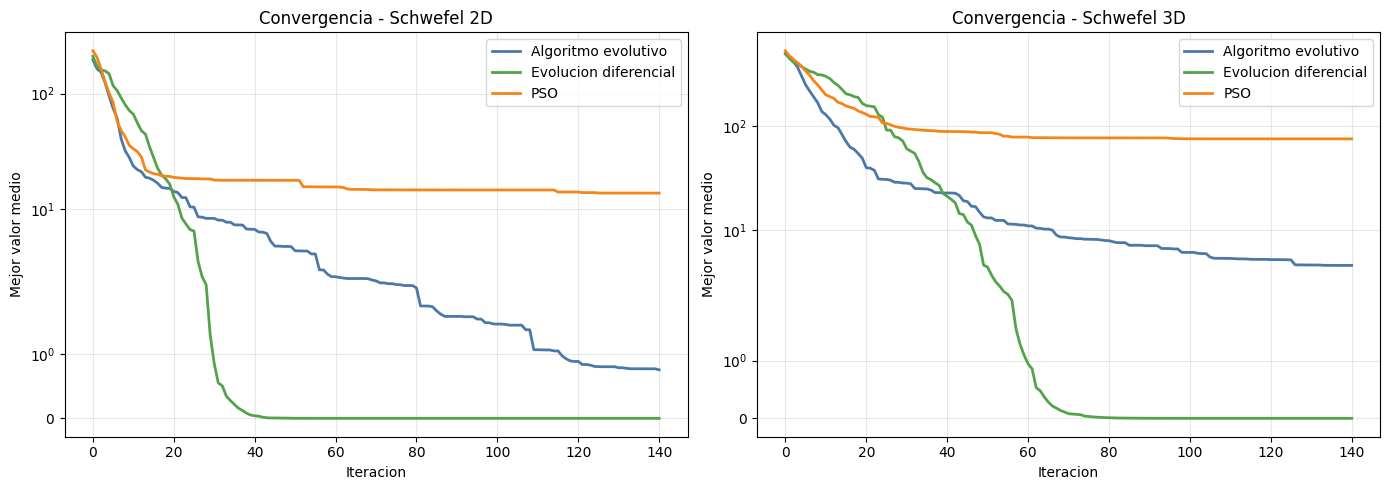

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/heuristicos/datos/figuras/convergencia_schwefel_2d_3d.png')

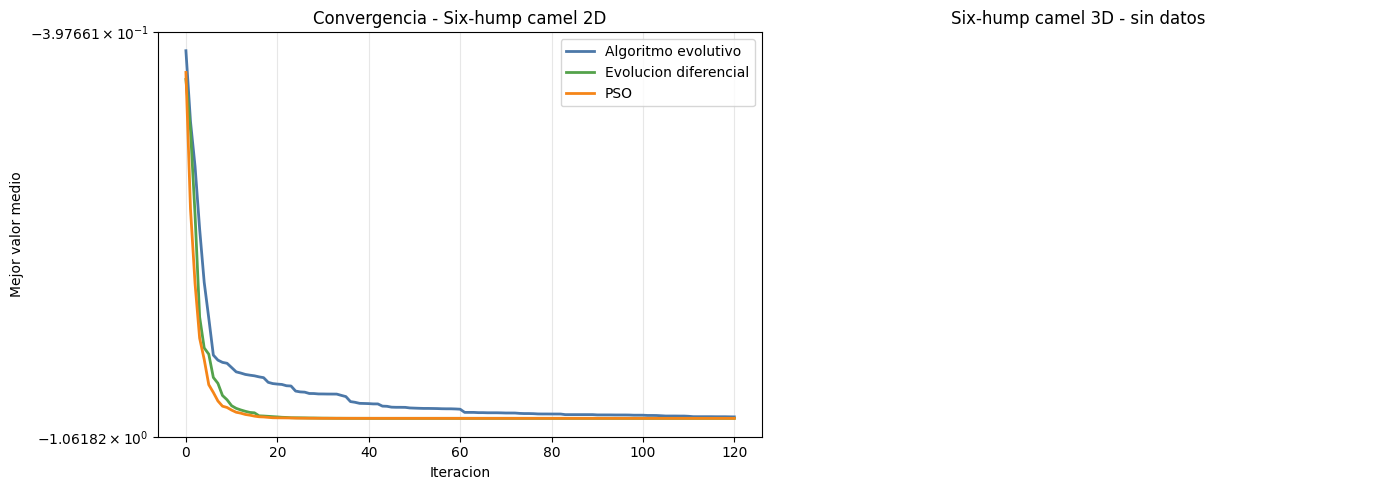

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/heuristicos/datos/figuras/convergencia_six-hump camel_2d_3d.png')

In [ ]:
if has_histories:
    convergence_rows = [
        row for row in json_runs
        if "best_values_history" in row and row["best_values_history"]
    ]

    funciones = sorted({str(row["nombre_funcion"]).lower() for row in convergence_rows})

    for funcion in funciones:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        dimensiones = [2, 3]

        for ax, dim in zip(axes, dimensiones):
            case_rows = [
                row for row in convergence_rows
                if str(row["nombre_funcion"]).lower() == funcion
                and int(row["dimension"]) == dim
            ]

            if not case_rows:
                ax.set_title(f"{funcion.capitalize()} {dim}D - sin datos")
                ax.axis("off")
                continue

            for method_name in sorted({row["nombre_metodo"] for row in case_rows}):
                method_histories = [
                    np.asarray(row["best_values_history"], dtype=float)
                    for row in case_rows
                    if row["nombre_metodo"] == method_name
                ]

                min_length = min(len(history) for history in method_histories)
                aligned = np.vstack([history[:min_length] for history in method_histories])
                mean_history = aligned.mean(axis=0)

                color = method_colors.get(method_name, "#777777")
                ax.plot(mean_history, label=method_name, linewidth=2, color=color)

            ax.set_title(f"Convergencia - {funcion.capitalize()} {dim}D")
            ax.set_xlabel("Iteracion")
            ax.set_ylabel("Mejor valor medio")
            ax.set_yscale("symlog")
            ax.grid(alpha=0.3)
            ax.legend()

        plt.tight_layout()
        fig_path = save_current_figure(f"convergencia_{funcion}_2d_3d.png")
        plt.show()
        display(fig_path)
else:
    print("No se encontraron historiales.")

## Exportables utiles para el reporte

In [ ]:
tabla_reporte_path = FIGURES_DIR / "tabla_resumen_heuristicos.csv"
ranking_path = FIGURES_DIR / "ranking_por_caso.csv"
mejores_path = FIGURES_DIR / "mejores_casos.csv"
peores_path = FIGURES_DIR / "peores_casos.csv"

tabla_reporte.to_csv(tabla_reporte_path, index=False, encoding="utf-8")
ranking_por_caso.to_csv(ranking_path, index=False, encoding="utf-8")
mejores_casos.to_csv(mejores_path, index=False, encoding="utf-8")
peores_casos.to_csv(peores_path, index=False, encoding="utf-8")

print("Archivos exportados:")
print("-", tabla_reporte_path)
print("-", ranking_path)
print("-", mejores_path)
print("-", peores_path)

Archivos exportados:
- c:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\tabla_resumen_heuristicos.csv
- c:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\ranking_por_caso.csv
- c:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\mejores_casos.csv
- c:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\peores_casos.csv


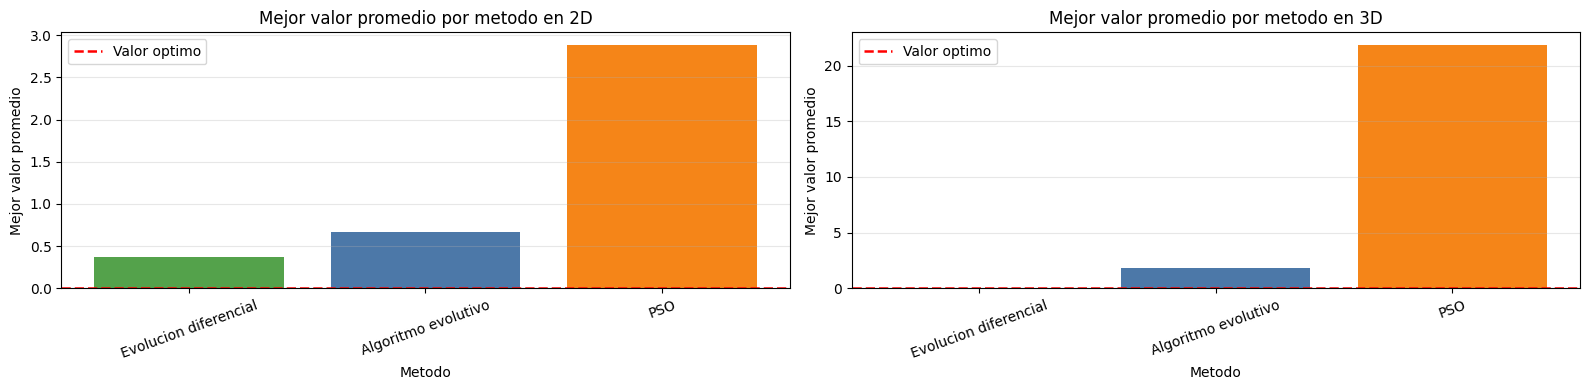

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/heuristicos/datos/figuras/mejor_valor_promedio_por_metodo_2d_3d.png')

In [ ]:
# Graficas de barras del mejor valor promedio por metodo:
# izquierda = 2D, derecha = 3D

data_2d = summary_df[
    summary_df["caso_n"].astype(str).str.contains("2d", case=False, na=False)
].copy()

data_3d = summary_df[
    summary_df["caso_n"].astype(str).str.contains("3d", case=False, na=False)
].copy()

resumen_2d = (
    data_2d.groupby("nombre_metodo", as_index=False)["promedio_valor"]
    .mean()
    .sort_values("promedio_valor")
)

resumen_3d = (
    data_3d.groupby("nombre_metodo", as_index=False)["promedio_valor"]
    .mean()
    .sort_values("promedio_valor")
)

valor_optimo_2d = 0
valor_optimo_3d = 0

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)

colors_2d = [method_colors.get(name, "#777777") for name in resumen_2d["nombre_metodo"]]
colors_3d = [method_colors.get(name, "#777777") for name in resumen_3d["nombre_metodo"]]

axes[0].bar(resumen_2d["nombre_metodo"], resumen_2d["promedio_valor"], color=colors_2d)
axes[0].axhline(valor_optimo_2d, color="red", linestyle="--", linewidth=1.8, label="Valor optimo")
axes[0].set_title("Mejor valor promedio por metodo en 2D")
axes[0].set_xlabel("Metodo")
axes[0].set_ylabel("Mejor valor promedio")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].bar(resumen_3d["nombre_metodo"], resumen_3d["promedio_valor"], color=colors_3d)
axes[1].axhline(valor_optimo_3d, color="red", linestyle="--", linewidth=1.8, label="Valor optimo")
axes[1].set_title("Mejor valor promedio por metodo en 3D")
axes[1].set_xlabel("Metodo")
axes[1].set_ylabel("Mejor valor promedio")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
fig_path = save_current_figure("mejor_valor_promedio_por_metodo_2d_3d.png")
plt.show()
fig_path

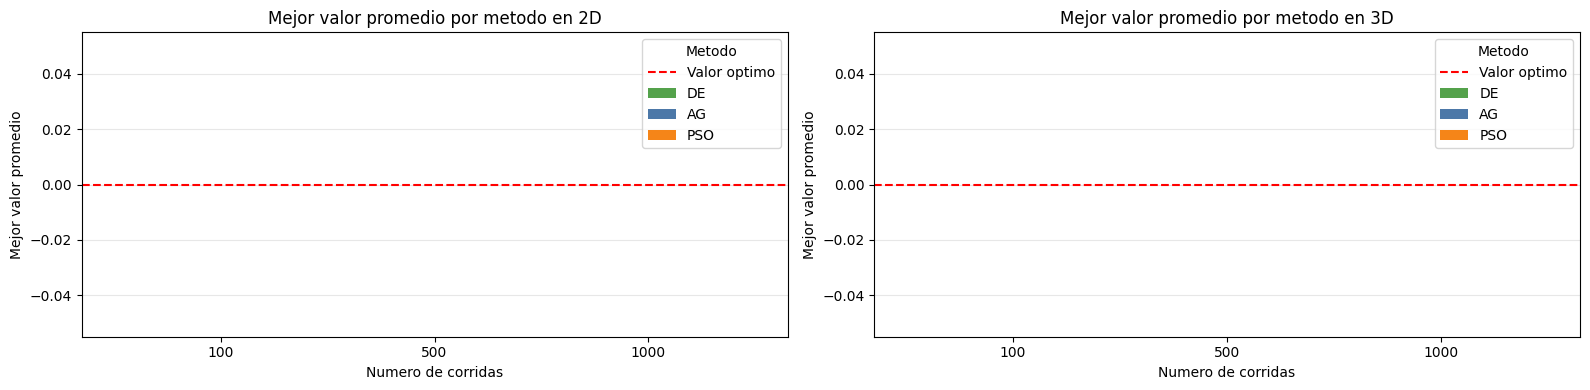

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/heuristicos/datos/figuras/mejor_valor_promedio_por_metodo_2d_3d_y_corridas.png')

In [ ]:
# Grafica completa:
# izquierda = 2D, derecha = 3D
# eje x = numero de corridas (100, 500, 1000)
# barras = metodo
# y = promedio_valor

plot_df = summary_df.copy()

plot_df["dimension"] = plot_df["caso_n"].astype(str).str.extract(r"(2d|3d)", expand=False)
plot_df["n_corridas"] = pd.to_numeric(
    plot_df["caso_n"].astype(str).str.extract(r"n(\d+)", expand=False),
    errors="coerce"
)

plot_df["metodo_plot"] = (
    plot_df["nombre_metodo"]
    .astype(str)
    .str.lower()
    .replace({
        "evolucion diferencial": "DE",
        "algoritmo evolutivo": "AG",
        "pso": "PSO",
        "de": "DE",
        "ea": "AG",
        "ag": "AG"
    })
)

plot_df = plot_df.dropna(subset=["dimension", "n_corridas", "promedio_valor"])
plot_df["n_corridas"] = plot_df["n_corridas"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)

orden_n = [100, 500, 1000]
orden_metodos = ["DE", "AG", "PSO"]
colores = {
    "DE": "#54A24B",
    "AG": "#4C78A8",
    "PSO": "#F58518"
}

for ax, dim in zip(axes, ["2d", "3d"]):
    data_dim = plot_df[plot_df["dimension"] == dim].copy()

    pivot_vals = (
        data_dim.pivot_table(
            index="n_corridas",
            columns="metodo_plot",
            values="promedio_valor",
            aggfunc="mean"
        )
        .reindex(index=orden_n, columns=orden_metodos)
    )

    pivot_vals.plot(
        kind="bar",
        ax=ax,
        width=0.8,
        color=[colores.get(col, "#777777") for col in pivot_vals.columns]
    )

    ax.axhline(0, color="red", linestyle="--", linewidth=1.5, label="Valor optimo")
    ax.set_title(f"Mejor valor promedio por metodo en {dim.upper()}")
    ax.set_xlabel("Numero de corridas")
    ax.set_ylabel("Mejor valor promedio")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Metodo")

plt.tight_layout()
fig_path = save_current_figure("mejor_valor_promedio_por_metodo_2d_3d_y_corridas.png")
plt.show()
fig_path

In [ ]:
print(summary_df["dimension"].drop_duplicates().tolist())
print(summary_df["n_corridas"].drop_duplicates().tolist())
print(summary_df["nombre_metodo"].drop_duplicates().tolist())

[2, 3]
[100, 500, 1000]
['Evolucion diferencial', 'Algoritmo evolutivo', 'PSO']


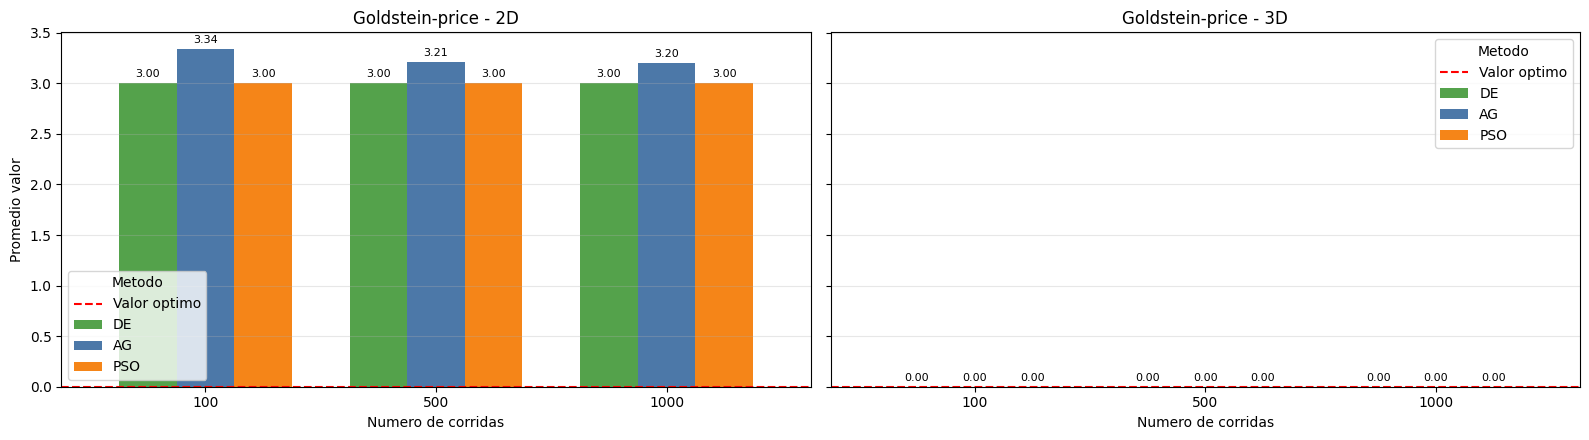

c:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\goldstein-price_2d_3d_corridas.png


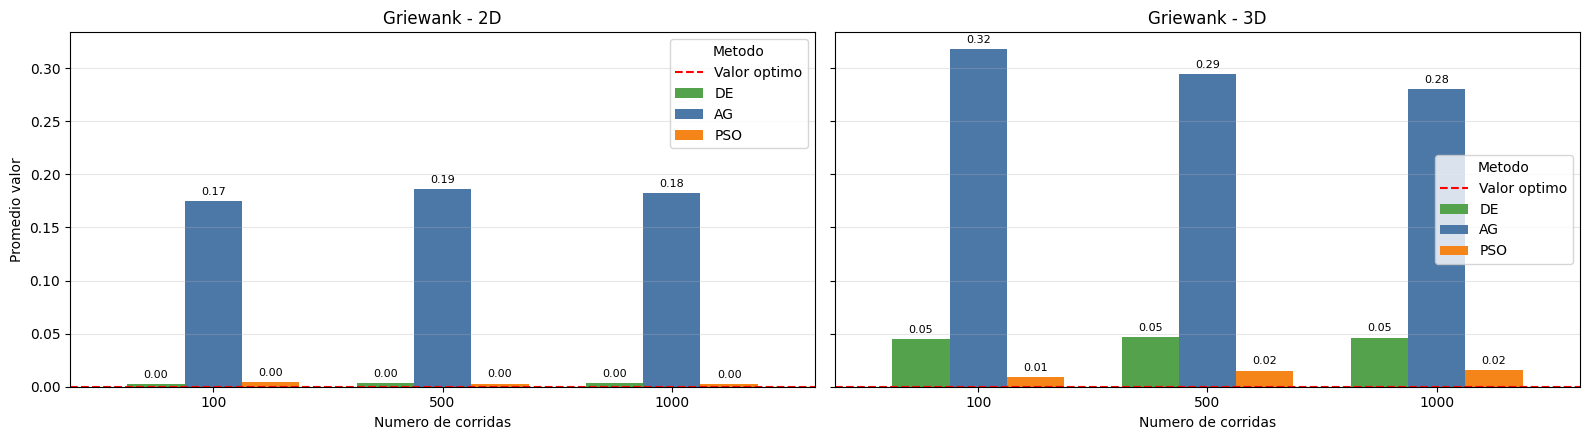

c:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\griewank_2d_3d_corridas.png


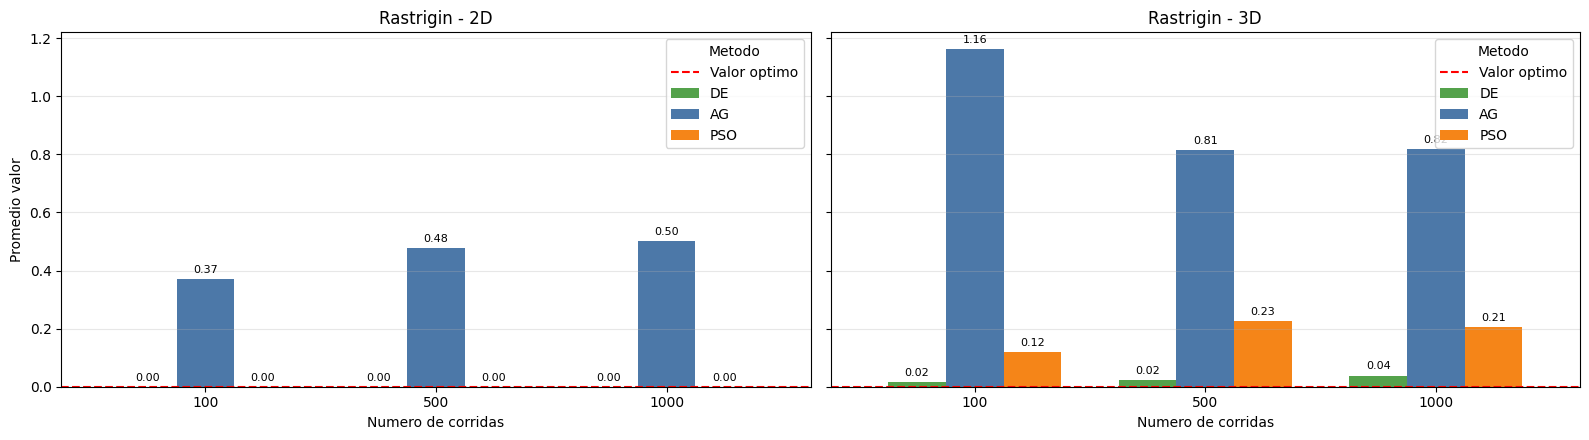

c:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\rastrigin_2d_3d_corridas.png


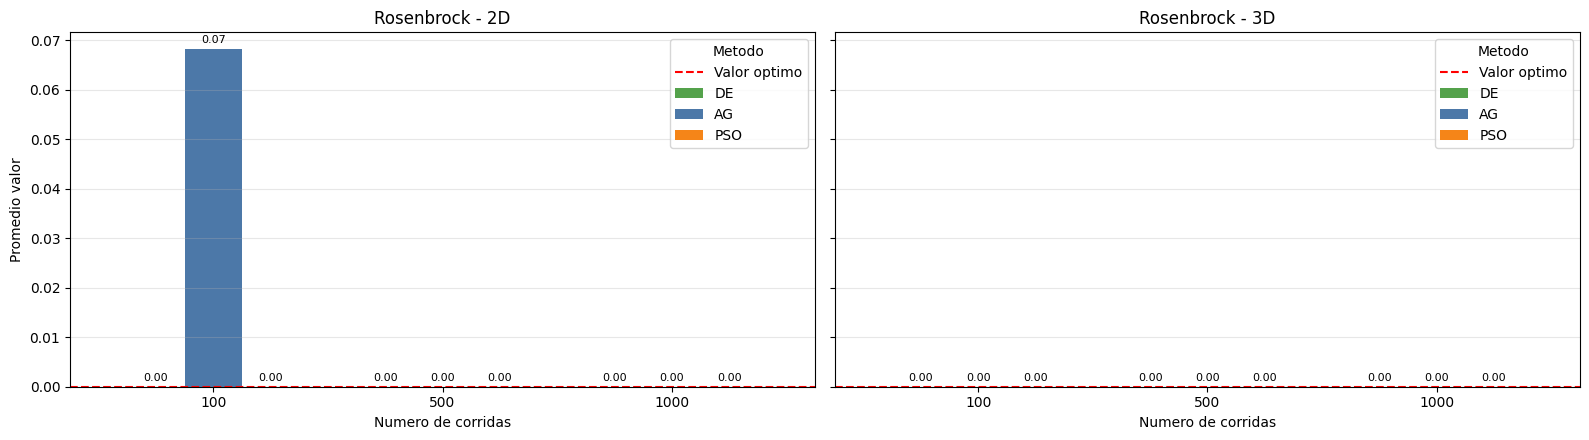

c:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\rosenbrock_2d_3d_corridas.png


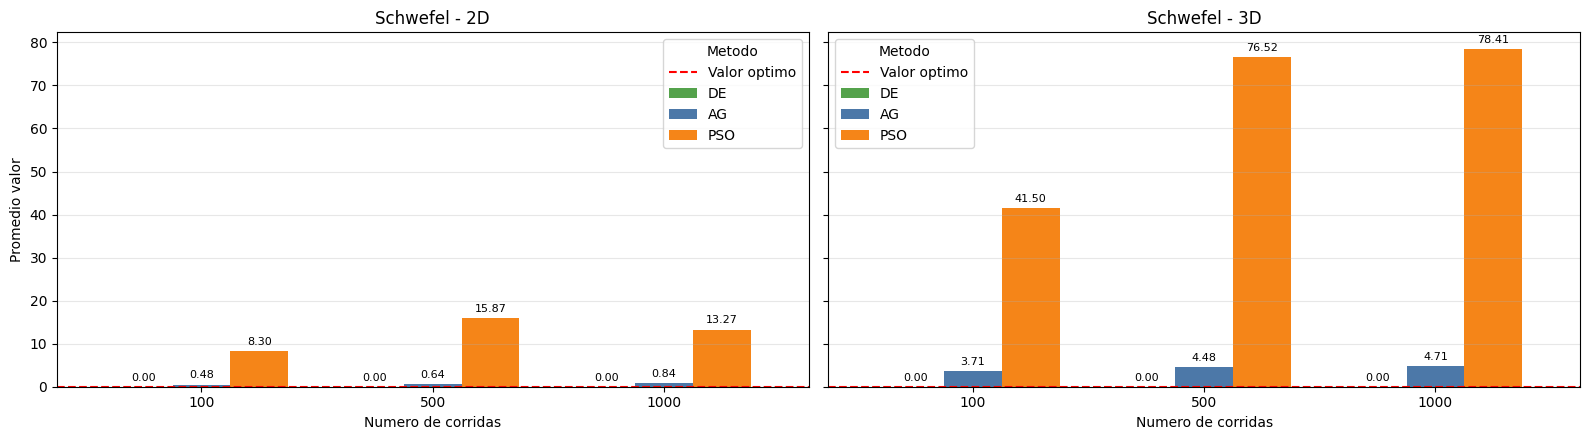

c:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\schwefel_2d_3d_corridas.png


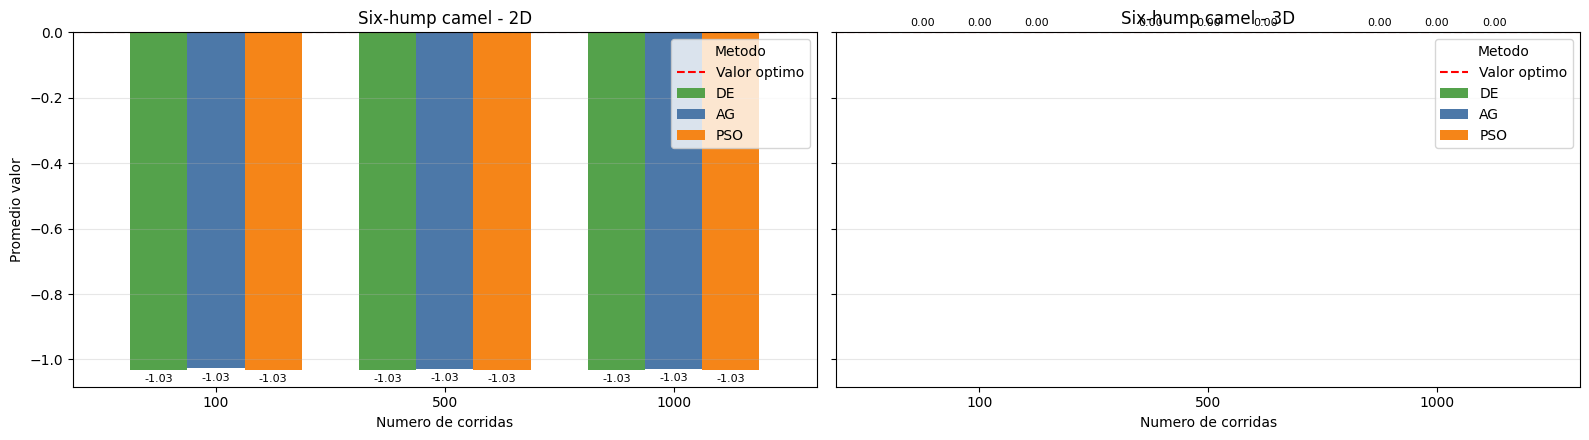

c:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\six-hump camel_2d_3d_corridas.png


In [ ]:
funciones = sorted(summary_df["nombre_funcion"].dropna().astype(str).unique())

orden_n = [100, 500, 1000]
orden_metodos = ["DE", "AG", "PSO"]
colores = {
    "DE": "#54A24B",
    "AG": "#4C78A8",
    "PSO": "#F58518"
}

for funcion in funciones:
    plot_df = summary_df[
        summary_df["nombre_funcion"].astype(str).str.lower() == funcion.lower()
    ].copy()

    plot_df["metodo_plot"] = (
        plot_df["nombre_metodo"]
        .astype(str)
        .str.lower()
        .replace({
            "evolucion diferencial": "DE",
            "algoritmo evolutivo": "AG",
            "pso": "PSO",
            "de": "DE",
            "ea": "AG",
            "ag": "AG"
        })
    )

    plot_df = plot_df.dropna(subset=["dimension", "n_corridas", "promedio_valor"]).copy()
    plot_df["n_corridas"] = pd.to_numeric(plot_df["n_corridas"], errors="coerce")
    plot_df = plot_df.dropna(subset=["n_corridas"])
    plot_df["n_corridas"] = plot_df["n_corridas"].astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), sharey=True)

    for ax, dim, titulo in zip(axes, [2, 3], ["2D", "3D"]):
        data_dim = plot_df[plot_df["dimension"] == dim].copy()

        pivot_vals = (
            data_dim.pivot_table(
                index="n_corridas",
                columns="metodo_plot",
                values="promedio_valor",
                aggfunc="mean"
            )
            .reindex(index=orden_n, columns=orden_metodos)
        )

        pivot_vals.plot(
            kind="bar",
            ax=ax,
            width=0.75,
            color=[colores.get(col, "#777777") for col in pivot_vals.columns]
        )

        ax.axhline(0, color="red", linestyle="--", linewidth=1.5, label="Valor optimo")
        ax.set_title(f"{funcion.capitalize()} - {titulo}", fontsize=12)
        ax.set_xlabel("Numero de corridas", fontsize=10)
        ax.set_ylabel("Promedio valor", fontsize=10)
        ax.tick_params(axis="x", rotation=0)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(title="Metodo", frameon=True)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)

    plt.tight_layout()
    fig_path = save_current_figure(f"{funcion.lower()}_2d_3d_corridas.png")
    plt.show()
    print(fig_path)